In [5]:
import numpy as np
import pandas as pd
import scipy as sp
import qnm
import sxs
import h5py
from scipy import interpolate
import pickle

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
from itertools import combinations_with_replacement

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.rcParams['figure.max_open_warning'] = 0

plt.rcParams['text.usetex']        = True

# plt.rcParams['mathtext.fontset']  = 'stix'
# plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

label_data = 'h_{22}'

COL = {
    'NR': 'k',
    't_amp_peak': 'royalblue',
    't_flex': 'forestgreen',
}

alpha_std = 1
alpha_med = 0.8
alpha_low = 0.9

LS = {
    't': '--',
    'f': '--',
}

LW = {
    'small': 1.25,
    'medium': 1.2,
    'std': 1.8,
    'large': 2.5,
}

FONTS = {
    'legend': 18,
    'labels': 23,
}

plot_std = dict(c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
vline_peak = dict(lw=LW['small'], alpha=alpha_std, ls=LS['t'])

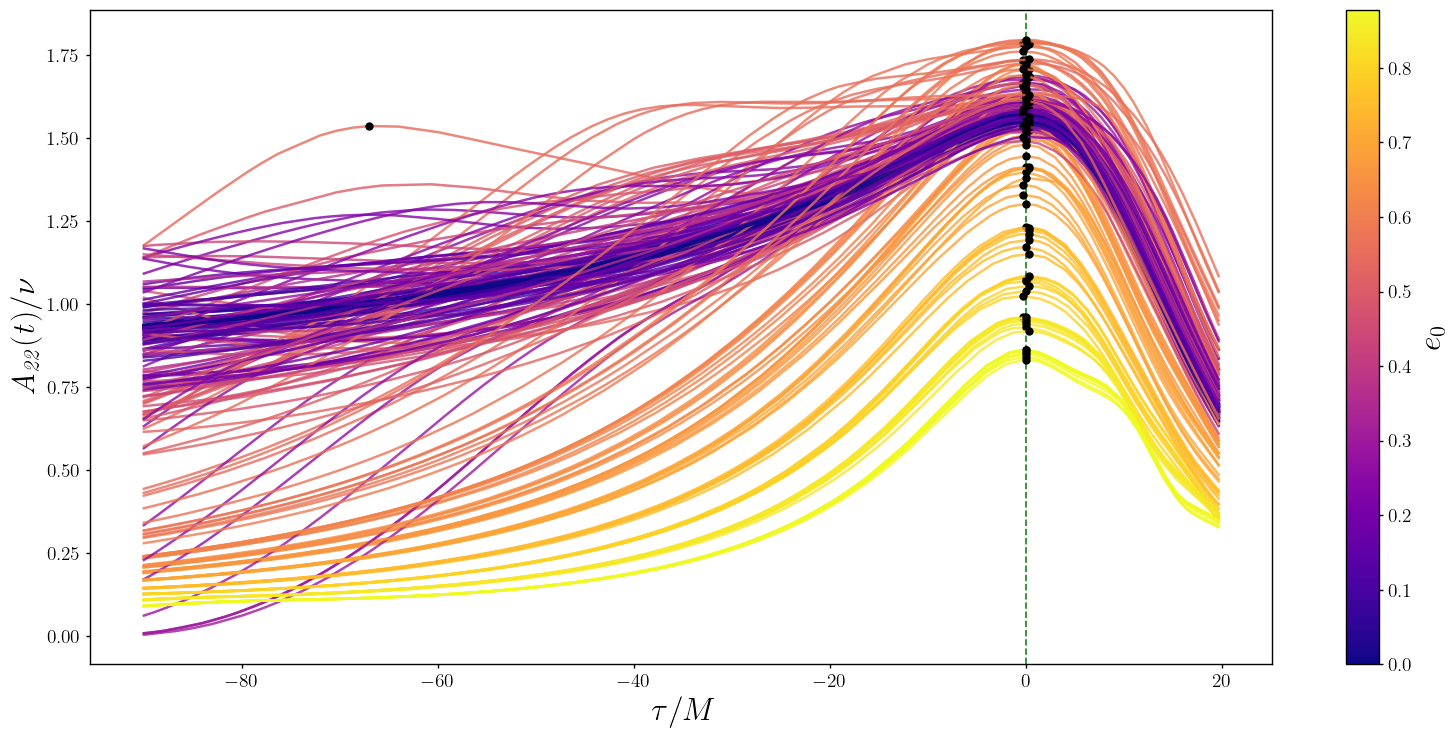

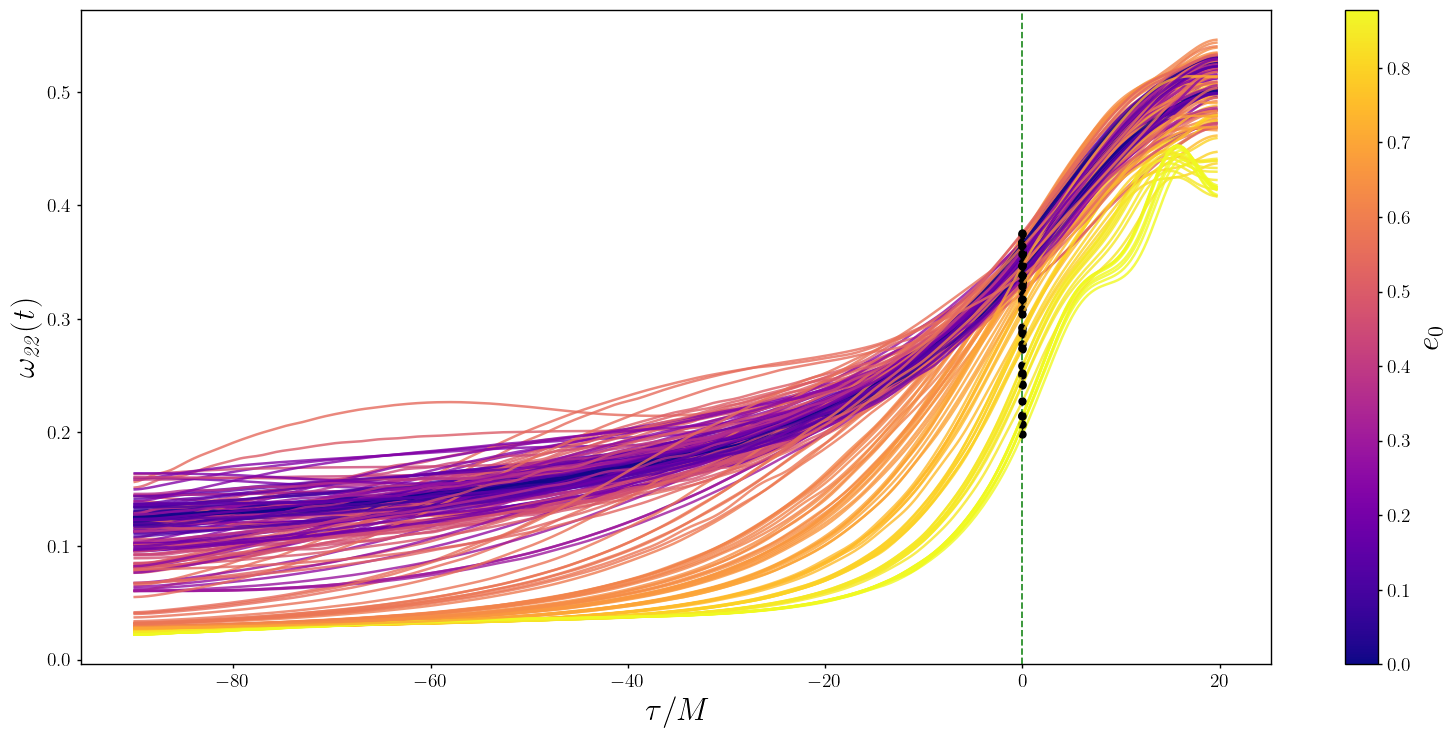

In [7]:
df = pd.read_csv('../src/data/RIT_Parameters_non-spinning.csv')
df.set_index('ID', inplace=True)
masks = df['catalog'] == 'RIT'
rit_ids = df.index
ecc = df.loc[rit_ids, 'ecc'].values

# idx = np.linspace(0, len(ecc[np.argsort(ecc)]) - 1, 20, dtype=int)
# ecc = ecc[np.argsort(ecc)][idx]
# rit_ids = rit_ids[idx]

ecc_min, ecc_max = np.nanmin(ecc), np.nanmax(ecc)
norm = mcolors.Normalize(vmin=ecc_min, vmax=ecc_max)
cmap = cm.plasma

fig_amp, ax_amp = plt.subplots(1, 1, figsize=(16, 8))
fig_freq, ax_freq = plt.subplots(1, 1, figsize=(16, 8))

ax_amp.axvline(0.0, c=COL['t_flex'], **vline_peak, label=r'$t_{\rm flex}$')
ax_freq.axvline(0.0, c=COL['t_flex'], **vline_peak, label=r'$t_{\rm flex}$')

for rit_id, ecc_val in zip(rit_ids, ecc):   
    try:                 
        metadata = {}
        with open(f'../../Metadata/RIT:eBBH:{rit_id}-n100-ecc_Metadata.txt', 'r') as f:
            lines = [l for l in f.readlines() if l.strip()]
            for line in lines[1:]:
                if line[0]=="#": continue
                line = line.rstrip("\n")
                key, val = line.split("= ")
                key = key.strip()
                metadata[key] = val

        fn = f'../../Data//ExtrapStrain_RIT-eBBH-{rit_id}-n100.h5'
        f      = h5py.File(fn, "r")
        u   =  f['NRTimes'][:]
        A   =  f[f'amp_l2_m2']['Y'][:]
        A_u =  f[f'amp_l2_m2']['X'][:]
        p   = -f[f'phase_l2_m2']['Y'][:]
        p_u =  f[f'phase_l2_m2']['X'][:]

        p  = sp.interpolate.interp1d(p_u, p)(u)
        A  = sp.interpolate.interp1d(A_u, A)(u)
        t_NR, NR_r, NR_i, NR_amp, NR_phase = u, A*np.cos( p), A*np.sin(-p), A, p
        
        q = float(metadata['initial-mass2']) / float(metadata['initial-mass1'])
        nu = q / (1 + q)**2
        
        tM_start, tM_end = -90, 20

        try:
            peak_height_threshold = np.max(NR_amp) * 0.5
            peaks, _              = sp.signal.find_peaks(NR_amp, height=peak_height_threshold)
            idx_amp_max           = peaks[-1] # the merger is the last peak of A_22
        except:
            idx_amp_max  = np.argmax(NR_amp) 
            
        t_amp_peak = t_NR[idx_amp_max]
        t_min, t_max = t_amp_peak + tM_start, t_amp_peak + tM_end
        
        idx_min, idx_max = np.where((t_NR - t_min)>=0)[0][0], np.where((t_NR - t_max)<=0)[0][-1]

        NR_phi_ref = np.unwrap(np.angle(NR_r - 1j*NR_i))[idx_min:idx_max]
        NR_f_ref = np.gradient(NR_phi_ref, t_NR[idx_min:idx_max]) / (2.0*np.pi)

        omega = NR_f_ref * (2*np.pi)
        omega_smooth    = sp.ndimage.gaussian_filter1d(omega, 0.8*np.std(omega))
        omega_smooth_d2 = np.gradient(np.gradient(omega_smooth))

        inflection_points = np.where(np.diff(np.sign(omega_smooth_d2)))

        t_flex = t_NR[idx_min:idx_max][inflection_points][np.argmin(np.abs(t_NR[idx_min:idx_max][inflection_points] - t_amp_peak))]

        t_min, t_max = t_flex + tM_start, t_flex + tM_end
        idx_min, idx_max = np.where((t_NR - t_min)>=0)[0][0], np.where((t_NR - t_max)<=0)[0][-1]

        tau = t_NR[idx_min:idx_max] - t_flex
        NR_amp = np.abs(NR_r - 1j*NR_i)[idx_min:idx_max]
        NR_phi = np.unwrap(np.angle(NR_r - 1j*NR_i))[idx_min:idx_max]
        NR_f = np.gradient(NR_phi, t_NR[idx_min:idx_max]) / (2.0*np.pi)

        if (np.max(NR_f) < 1/(2*np.pi)):
            ax_amp.plot(tau, NR_amp/nu, color=cmap(norm(ecc_val)), lw=LW['std'], alpha=alpha_med, ls='-')
            ax_amp.plot(tau[np.argmax(NR_amp)], NR_amp[np.argmax(NR_amp)]/nu, marker='o', markersize=5, c='k')

            omega_smooth = sp.ndimage.gaussian_filter1d(NR_f*(2*np.pi), 200*np.std(NR_f))
            ax_freq.plot(tau, omega_smooth, color=cmap(norm(ecc_val)), lw=LW['std'], alpha=alpha_med, ls='-')
            ax_freq.plot(t_flex - t_flex, omega_smooth[np.argmin(np.abs(t_NR[idx_min:idx_max] - t_flex))], marker='o', markersize=5, c='k')

    except Exception as e:
        print(f"Error processing RIT:eBBH:{rit_id}: {e}")
        continue

plt.figure(fig_amp.number)
ax_amp.set_ylabel(r'$\mathit{A_{22}(t)}/\nu$', fontsize=FONTS['labels'])
ax_amp.set_xlabel(r'$\tau/M$', fontsize=FONTS['labels'])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_amp = fig_amp.colorbar(sm, ax=ax_amp)
cbar_amp.set_label(r'$e_0$', fontsize=FONTS['labels'])

plt.rcParams['legend.frameon'] = True
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0, wspace=0.27)
#fig_amp.savefig("amplitude_eccentricity.pdf", bbox_inches='tight')

plt.figure(fig_freq.number)
ax_freq.set_ylabel(r'$\mathit{\omega_{22}(t)}$', fontsize=FONTS['labels'])
ax_freq.set_xlabel(r'$\tau/M$', fontsize=FONTS['labels'])
cbar_freq = fig_freq.colorbar(sm, ax=ax_freq)
cbar_freq.set_label(r'$e_0$', fontsize=FONTS['labels'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0, wspace=0.27)
#fig_freq.savefig("frequency_eccentricity.pdf", bbox_inches='tight')

plt.show()

In [4]:
# df = pd.read_csv('../src/data/SXS_Parameters_non-spinning.csv')
# df.set_index('ID', inplace=True)
# masks = df['catalog'] == 'SXS'
# sxs_ids = df.index
# ecc = df.loc[sxs_ids, 'ecc'].values

# # idx = np.linspace(0, len(ecc[np.argsort(ecc)]) - 1, 20, dtype=int)
# # ecc = ecc[np.argsort(ecc)][idx]
# # sxs_ids = sxs_ids[idx]

# ecc_min, ecc_max = np.nanmin(ecc), np.nanmax(ecc)
# norm = mcolors.Normalize(vmin=ecc_min, vmax=ecc_max)
# cmap = cm.plasma

# fig_amp, ax_amp = plt.subplots(1, 1, figsize=(12, 8))
# fig_freq, ax_freq = plt.subplots(1, 1, figsize=(12, 8))

# ax_amp.axvline(0.0, c=COL['t_flex'], **vline_peak, label=r'$t_{\rm flex}$')
# ax_freq.axvline(0.0, c=COL['t_flex'], **vline_peak, label=r'$t_{\rm flex}$')

# for sxs_id, ecc_val in zip(sxs_ids, ecc):                    
#     try:
#         sim = sxs.load(f"SXS:BBH:{sxs_id}/Lev3", extrapolation_order=2)
#         wf = sim.h
#         metadata = sim.metadata
#         index = wf.index(2, 2)
#         wf = wf[:, index]
        
#         t_NR = wf.t
#         q = metadata.initial_mass2 / metadata.initial_mass1
#         nu = q / (1 + q)**2
        
#         tM_start, tM_end = -100, 30

#         t_amp_peak = t_NR[np.argmax(np.abs(wf))]
#         t_min, t_max = t_amp_peak + tM_start, t_amp_peak + tM_end
        
#         idx_min, idx_max = np.where((t_NR - t_min)>=0)[0][0], np.where((t_NR - t_max)<=0)[0][-1]

#         NR_phi_ref = np.unwrap(np.angle(wf.real - 1j*wf.imag))[idx_min:idx_max]
#         NR_f_ref = np.gradient(NR_phi_ref, t_NR[idx_min:idx_max]) / (2.0*np.pi)

#         omega = NR_f_ref * (2*np.pi)
#         omega_smooth    = sp.ndimage.gaussian_filter1d(omega, 0.8*np.std(omega))
#         omega_smooth_d2 = np.gradient(np.gradient(omega_smooth))

#         inflection_points = np.where(np.diff(np.sign(omega_smooth_d2)))
            
#         t_flex = t_NR[idx_min:idx_max][inflection_points][np.argmin(np.abs(t_NR[idx_min:idx_max][inflection_points] - t_amp_peak))]

#         t_min, t_max = t_flex + tM_start, t_flex + tM_end
#         idx_min, idx_max = np.where((t_NR - t_min)>=0)[0][0], np.where((t_NR - t_max)<=0)[0][-1]

#         tau = t_NR[idx_min:idx_max] - t_flex
#         NR_amp = np.abs(wf.real - 1j*wf.imag)[idx_min:idx_max]
#         NR_phi = np.unwrap(np.angle(wf.real - 1j*wf.imag))[idx_min:idx_max]
#         NR_f = np.gradient(NR_phi, t_NR[idx_min:idx_max]) / (2.0*np.pi)

#         ax_amp.plot(tau, NR_amp/nu, color=cmap(norm(ecc_val)), lw=LW['std'], alpha=alpha_med, ls='-')
#         ax_amp.plot(tau[np.argmax(NR_amp)], NR_amp[np.argmax(NR_amp)]/nu, marker='o', markersize=5, c='k')

#         ax_freq.plot(tau, NR_f*(2*np.pi), color=cmap(norm(ecc_val)), lw=LW['std'], alpha=alpha_med, ls='-')
#         ax_freq.plot(t_flex - t_flex, NR_f[np.argmin(np.abs(t_NR[idx_min:idx_max] - t_flex))]*(2*np.pi), marker='o', markersize=5, c='k')

#     except Exception as e:
#         print(f"Error processing SXS:BBH:{sxs_id}: {e}")
#         continue

# plt.figure(fig_amp.number)
# ax_amp.set_ylabel(r'$\mathit{A_{22}(t)}/\nu$', fontsize=FONTS['labels'])
# ax_amp.set_xlabel(r'$\tau/M$', fontsize=FONTS['labels'])
# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar_amp = fig_amp.colorbar(sm, ax=ax_amp)
# cbar_amp.set_label(r'$e_0$', fontsize=FONTS['labels'])

# plt.rcParams['legend.frameon'] = True
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.subplots_adjust(hspace=0, wspace=0.27)
# # fig_amp.savefig("amplitude_eccentricity.pdf", bbox_inches='tight')

# plt.figure(fig_freq.number)
# ax_freq.set_ylabel(r'$\mathit{\omega_{22}(t)}$', fontsize=FONTS['labels'])
# ax_freq.set_xlabel(r'$\tau/M$', fontsize=FONTS['labels'])
# cbar_freq = fig_freq.colorbar(sm, ax=ax_freq)
# cbar_freq.set_label(r'$e_0$', fontsize=FONTS['labels'])

# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.subplots_adjust(hspace=0, wspace=0.27)
# # fig_freq.savefig("frequency_eccentricity.pdf", bbox_inches='tight')

# plt.show()